# Команда 12. Смирнова М., Дворяшина И., Шумакова В., Шилкова А.

# Импорты библиотек

In [1]:
#pip install seaborn

  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.2.5-py3-none-any.whl.metadata (5.0 kB)
  Using cached pytz-2025.2-py2.py3-none-any.whl.metadata (22 kB)
  Using cached tzdata-2025.2-py2.py3-none-any.whl.metadata (1.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 9.3 MB/s eta 0:00:00a 0:00:01m
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 10.5 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 8.8 MB/s eta 0:00:00ta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 8.0 MB/s eta 0:00:00 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 10.4 MB/s eta 0:00:00a 0:00:01
Using cached pyparsing-3.2.5-py3-none-any.whl (113 kB)
Using cached pytz-2025.2-py2.py3-none-any.whl (509 kB)
Using cached tzdata-2025.2-py2.py3-none-any.whl (347 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12/12 [seaborn]1/12 [seaborn]ib]

[notice] 

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
import statsmodels.api as sm

# Чтение данных

In [13]:
df_path = "videostreaming_platform.csv"

df = pd.read_csv(df_path)

df.head()

,user_id,start_trial_date,city,device,source,favourite_genre,avg_min_watch_daily,number_of_days_logged,churn
0,d1b6ef34-1991-452a-8c39-c83c0d5805fe,2024-02-01,St Petersburg,ios,performance,drama,2.076642,4,1
1,f1bf2396-73d8-461e-a775-9f068bd99326,2024-02-01,Other,web,seo,criminal,5.101392,1,1
2,ec9fa0be-4bd8-4fe6-910a-e9e6d4bbba28,2024-02-01,Ufa,web,performance,criminal,2.906597,1,1
3,b0195e96-af2e-4ac3-8f60-26b8d862af84,2024-02-01,Moscow,smarttv,seo,thriller,2.702388,6,0
4,a208985a-7244-4291-8d38-64c8141e27b2,2024-02-01,Ufa,web,performance,thriller,10.237305,1,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                28000 non-null  object 
 1   start_trial_date       28000 non-null  object 
 2   city                   27692 non-null  object 
 3   device                 28000 non-null  object 
 4   source                 28000 non-null  object 
 5   favourite_genre        20048 non-null  object 
 6   avg_min_watch_daily    28000 non-null  float64
 7   number_of_days_logged  28000 non-null  int64  
 8   churn                  28000 non-null  int64  
dtypes: float64(1), int64(2), object(6)
memory usage: 1.9+ MB


In [6]:
# Проверка наличия пустых значений
print("Пропуски в данных: \n", df.isna().sum())

Пропуски в данных: 
 user_id                     0
start_trial_date            0
city                      308
device                      0
source                      0
favourite_genre          7952
avg_min_watch_daily         0
number_of_days_logged       0
churn                       0
dtype: int64


## Пропуски в данных обнаружены у признака 'city' (308) и 'favourite_genre' (7952)

In [7]:
df.describe()

,avg_min_watch_daily,number_of_days_logged,churn
count,28000.000000,28000.00000,28000.000000
mean,7.812663,1.88600,0.789286
std,7.739760,1.48293,0.407823
min,0.000181,1.00000,0.000000
25%,2.521966,1.00000,1.000000
50%,5.419012,1.00000,1.000000
75%,10.487946,2.00000,1.000000
max,80.072401,7.00000,1.000000


In [8]:
df.describe(include = 'object')

,user_id,start_trial_date,city,device,source,favourite_genre
count,28000,28000,27692,28000,28000,20048
unique,28000,28,9,4,3,5
top,d1b6ef34-1991-452a-8c39-c83c0d5805fe,2024-02-28,Moscow,web,performance,drama
freq,1,1103,8736,17752,14540,4928


In [9]:
print("Уникальные значения категориального признака city: ", df['city'].unique())
print("Уникальные значения категориального признака device: ", df['device'].unique())
print("Уникальные значения категориального признака source: ", df['source'].unique())
print("Уникальные значения категориального признака favourite_genre: ", df['favourite_genre'].unique())

Уникальные значения категориального признака city:  ['St Petersburg' 'Other' 'Ufa' 'Moscow' 'Samara' 'Krasnodar'
 'Yekaterinburg' 'Novosibirsk' 'Voronezh' nan]
Уникальные значения категориального признака device:  ['ios' 'web' 'smarttv' 'android']
Уникальные значения категориального признака source:  ['performance' 'seo' 'organic']
Уникальные значения категориального признака favourite_genre:  ['drama' 'criminal' 'thriller' 'comedy' nan 'action']


# Чистка данных

In [10]:
# Преобразование дат в datetime
df['start_trial_date'] = pd.to_datetime(df['start_trial_date'])

# Замена NaN на "Unknown"
df['city'] = df['city'].fillna('Unknown')
df['favourite_genre'] = df['favourite_genre'].fillna('Unknown')

# Feature Engineering
# Создание новой колонки день недели начала триала
df['trial_start_day_of_week'] = df['start_trial_date'].dt.dayofweek
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28000 entries, 0 to 27999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   user_id                  28000 non-null  object        
 1   start_trial_date         28000 non-null  datetime64[ns]
 2   city                     28000 non-null  object        
 3   device                   28000 non-null  object        
 4   source                   28000 non-null  object        
 5   favourite_genre          28000 non-null  object        
 6   avg_min_watch_daily      28000 non-null  float64       
 7   number_of_days_logged    28000 non-null  int64         
 8   churn                    28000 non-null  int64         
 9   trial_start_day_of_week  28000 non-null  int32         
dtypes: datetime64[ns](1), float64(1), int32(1), int64(2), object(5)
memory usage: 2.0+ MB


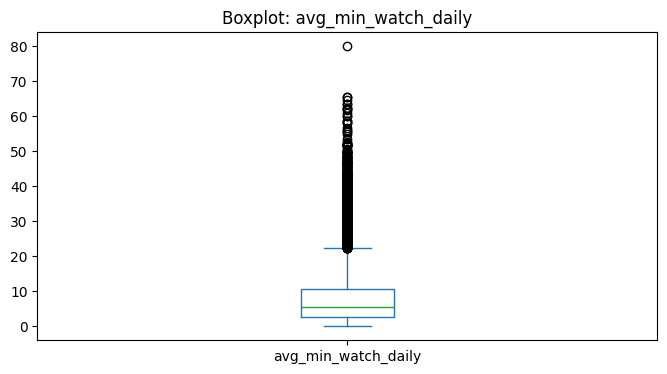

In [11]:
# Построение боксплота распределения и аномалии в данных о среднем времени просмотра
plt.figure(figsize=(8, 4))
df["avg_min_watch_daily"].plot(kind="box")
plt.title("Boxplot: avg_min_watch_daily")
plt.show()

In [12]:
# Расчет процентилей
percentiles = df['avg_min_watch_daily'].quantile([0.5, 0.75, 0.9, 0.95, 0.99, 0.999])
print("Процентили времени просмотра:")
print(percentiles)

Процентили времени просмотра:
0.500     5.419012
0.750    10.487946
0.900    18.095907
0.950    23.691268
0.990    36.007353
0.999    51.902463
Name: avg_min_watch_daily, dtype: float64


Поскольку 80 минут (максимальное значение) - адекватное время просмотра, и в целом для стриминга возможно скошенное распределение, принято решение не проводить очистку от выбросов и работать с исходными данными, чтобы не потерять полезную информацию для анализа конверсии

# Построение диаграмм категориальных признаков для анализа распределение данных

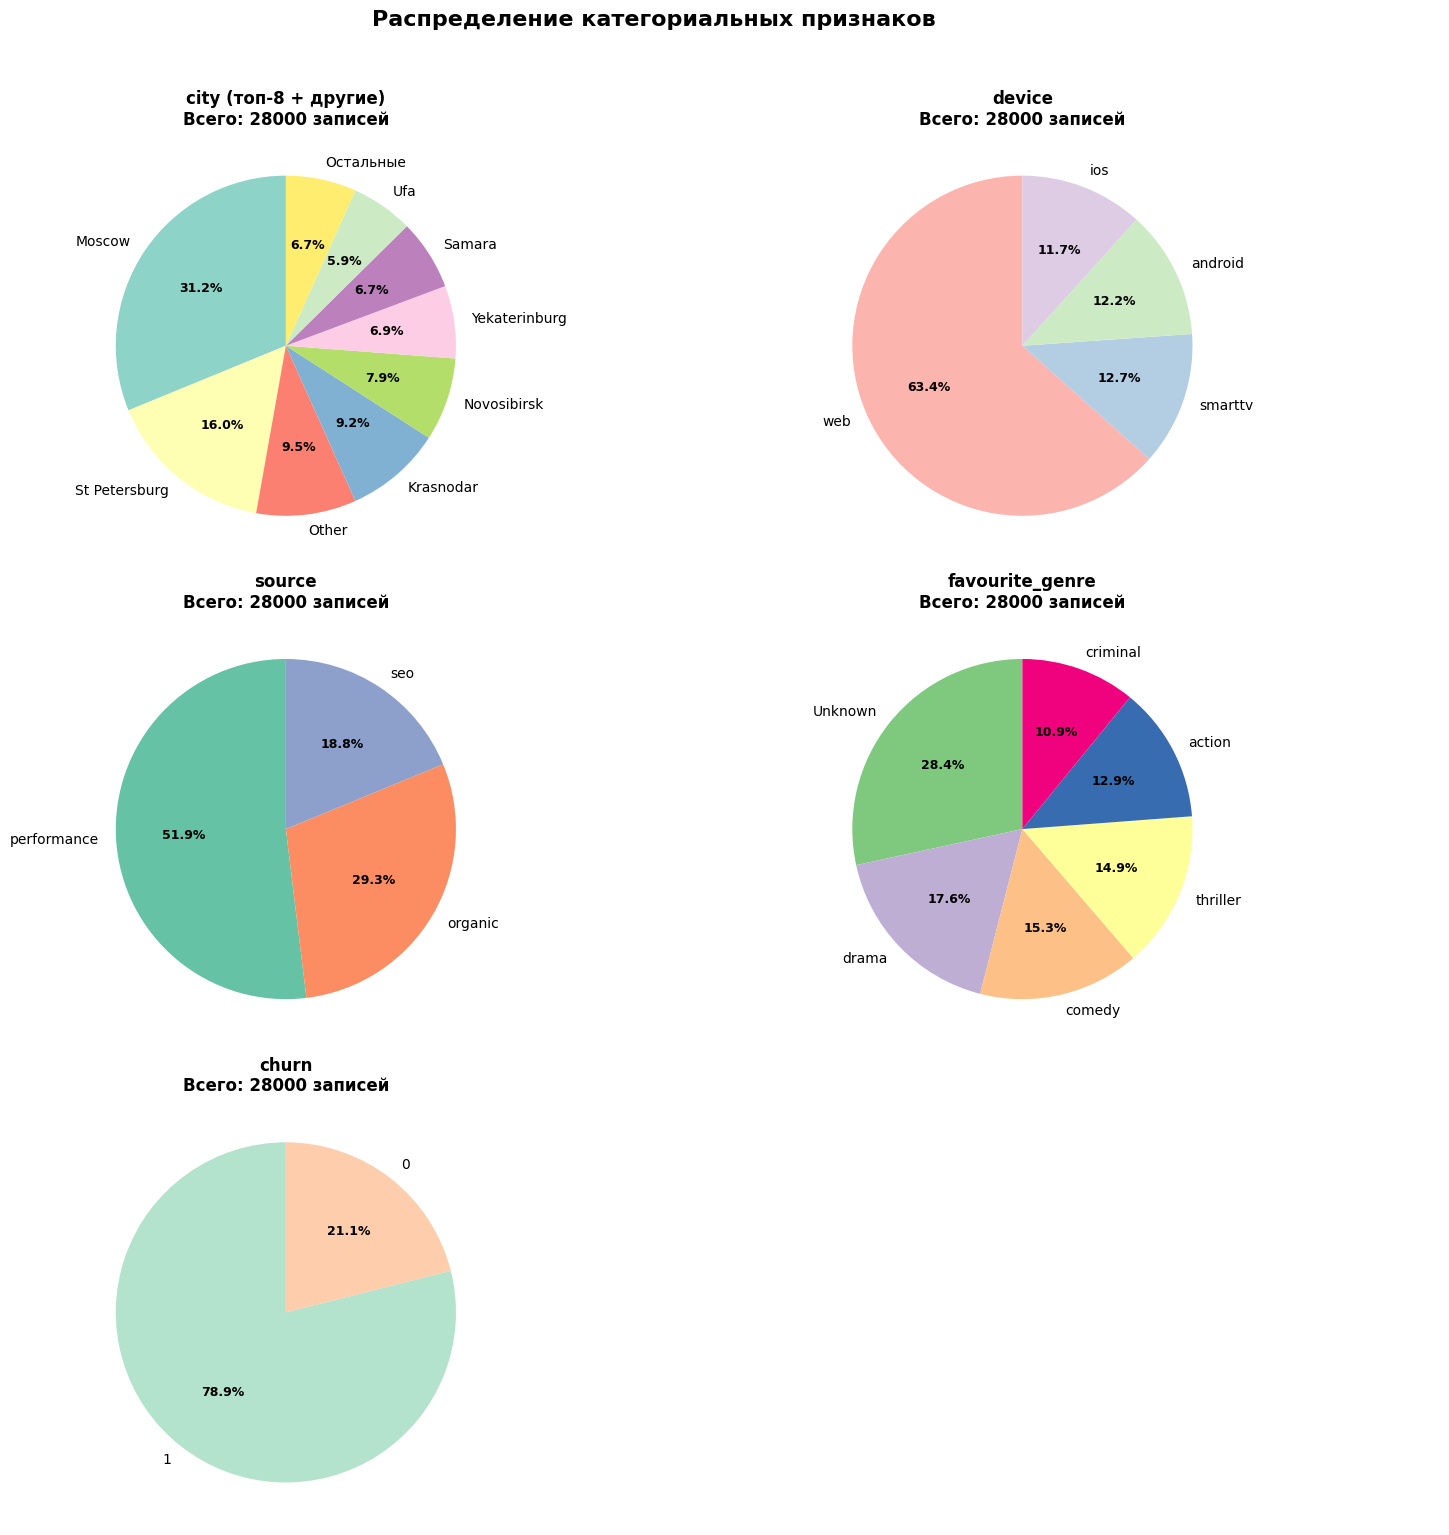

In [13]:
# Определяем категориальные признаки
categorical_columns = ['city', 'device', 'source', 'favourite_genre', 'churn']

fig, axes = plt.subplots(3, 2, figsize=(16, 15))
axes = axes.flatten()

color_palettes = [
    plt.cm.Set3,
    plt.cm.Pastel1,
    plt.cm.Set2,
    plt.cm.Accent,
    plt.cm.Pastel2
]

for i, col in enumerate(categorical_columns):
    if i < len(axes):
        ax = axes[i]

        # Получаем данные
        value_counts = df[col].value_counts()
        total = len(df[col])

        # Если уникальных значений много, показываем топ-8
        if len(value_counts) > 8:
            top_values = value_counts.head(8)
            others_count = value_counts[8:].sum()
            if others_count > 0:
                top_values['Остальные'] = others_count
            title_suffix = " (топ-8 + другие)"
        else:
            top_values = value_counts
            title_suffix = ""

        n_colors = len(top_values)
        if i < len(color_palettes):
            colors = color_palettes[i](np.linspace(0, 1, max(n_colors, 8)))
        else:
            colors = plt.cm.tab20c(np.linspace(0, 1, n_colors))

        colors = colors[:n_colors]

        wedges, texts, autotexts = ax.pie(top_values.values,
                                          labels=top_values.index.astype(str),
                                          autopct='%1.1f%%',
                                          startangle=90,
                                          colors=colors)

        ax.set_title(f'{col}{title_suffix}\nВсего: {total} записей',
                    fontsize=12, fontweight='bold')

        for autotext in autotexts:
            autotext.set_color('black')
            autotext.set_fontsize(9)
            autotext.set_fontweight('bold')

for i in range(len(categorical_columns), len(axes)):
    axes[i].axis('off')

plt.suptitle('Распределение категориальных признаков', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

**Все данные выглядят адекватно**

# Построение диаграмм числовых признаков для анализа распределение данных

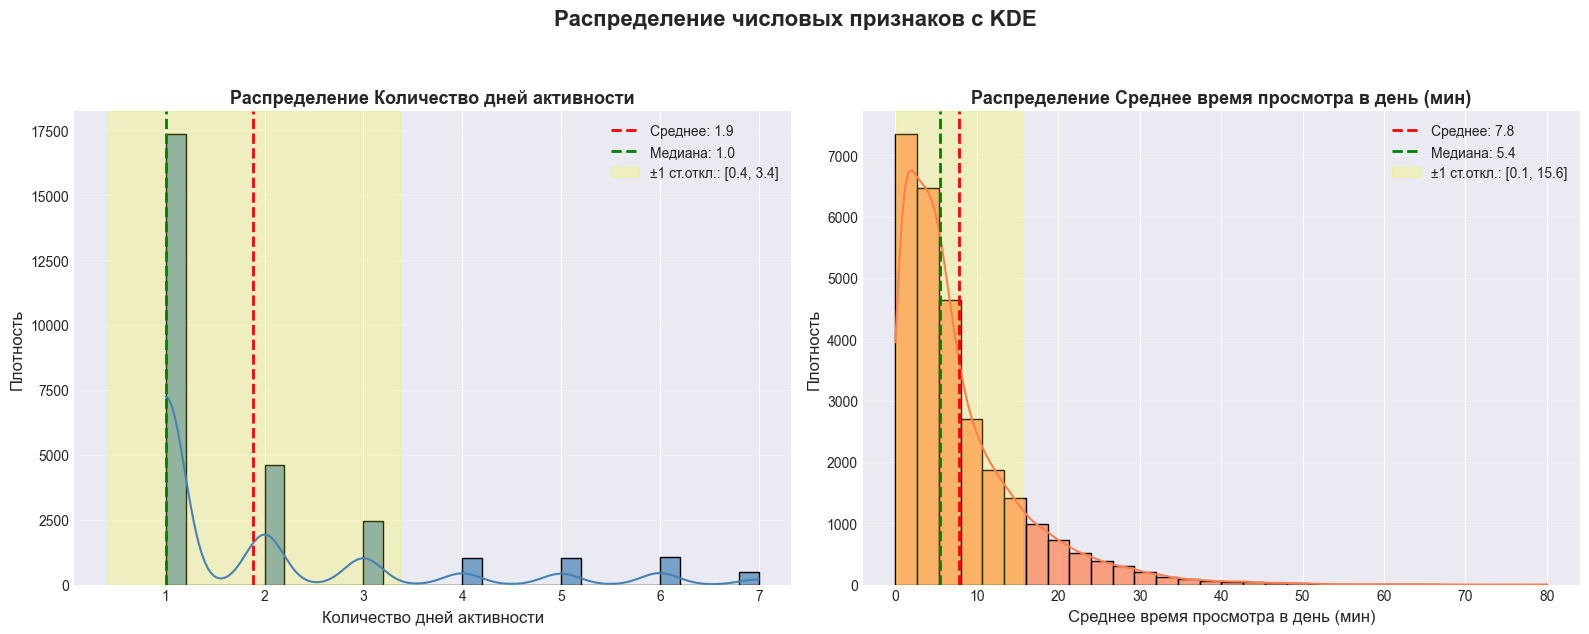


number_of_days_logged:

Асимметрия: 1.854 (сильно скошенное)
Эксцесс: 2.616

avg_min_watch_daily:

Асимметрия: 2.020 (сильно скошенное)
Эксцесс: 5.693


In [14]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Распределение числовых признаков с KDE', fontsize=16, fontweight='bold', y=1.05)

numeric_features = ['number_of_days_logged', 'avg_min_watch_daily']

colors = ['steelblue', 'coral']

for idx, (feature, color) in enumerate(zip(numeric_features, colors)):
    ax = axes[idx]

    sns.histplot(data=df, x=feature, bins=30,
                 kde=True, color=color, edgecolor='black', alpha=0.7, ax=ax)

    mean_val = df[feature].mean()
    median_val = df[feature].median()
    std_val = df[feature].std()

    feature_names = {
        'number_of_days_logged': 'Количество дней активности',
        'avg_min_watch_daily': 'Среднее время просмотра в день (мин)'
    }

    feature_name = feature_names.get(feature, feature)
    ax.set_title(f'Распределение {feature_name}', fontsize=13, fontweight='bold')
    ax.set_xlabel(feature_name, fontsize=12)
    ax.set_ylabel('Плотность', fontsize=12)

    # Добавляем линии для среднего и медианы
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2,
               label=f'Среднее: {mean_val:.1f}')
    ax.axvline(median_val, color='green', linestyle='--', linewidth=2,
               label=f'Медиана: {median_val:.1f}')

    # Добавляем область ±1 стандартное отклонение
    ax.axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='yellow',
               label=f'±1 ст.откл.: [{mean_val-std_val:.1f}, {mean_val+std_val:.1f}]')

    ax.legend(loc='upper right', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

for feature in numeric_features:
    print(f"\n{feature}:\n")

    # Асимметрия и эксцесс
    skewness = df[feature].skew()
    kurtosis = df[feature].kurtosis()

    skewness_interpretation = "симметричное" if abs(skewness) < 0.5 else \
                             "умеренно скошенное" if abs(skewness) < 1 else \
                             "сильно скошенное"

    print(f"Асимметрия: {skewness:.3f} ({skewness_interpretation})")
    print(f"Эксцесс: {kurtosis:.3f}")


**Все данные выглядят адекватно**

# Построение тепловой диаграммы, чтобы найти линейные зависимости между признаками

In [15]:
# Сначала сделаем one-hot преобразование категориальных признаков
categorical_cols = ['city', 'device', 'source', 'favourite_genre']
data_encoded = pd.get_dummies(df, columns=categorical_cols)

print(data_encoded.head())

                                user_id start_trial_date  avg_min_watch_daily  \
0  d1b6ef34-1991-452a-8c39-c83c0d5805fe       2024-02-01             2.076642   
1  f1bf2396-73d8-461e-a775-9f068bd99326       2024-02-01             5.101392   
2  ec9fa0be-4bd8-4fe6-910a-e9e6d4bbba28       2024-02-01             2.906597   
3  b0195e96-af2e-4ac3-8f60-26b8d862af84       2024-02-01             2.702388   
4  a208985a-7244-4291-8d38-64c8141e27b2       2024-02-01            10.237305   

   number_of_days_logged  churn  trial_start_day_of_week  city_Krasnodar  \
0                      4      1                        3           False   
1                      1      1                        3           False   
2                      1      1                        3           False   
3                      6      0                        3           False   
4                      1      1                        3           False   

   city_Moscow  city_Novosibirsk  city_Other  ...  devic

In [16]:
# Удалим колонку 'user_id', чтобы не мешала анализу
del data_encoded['user_id']

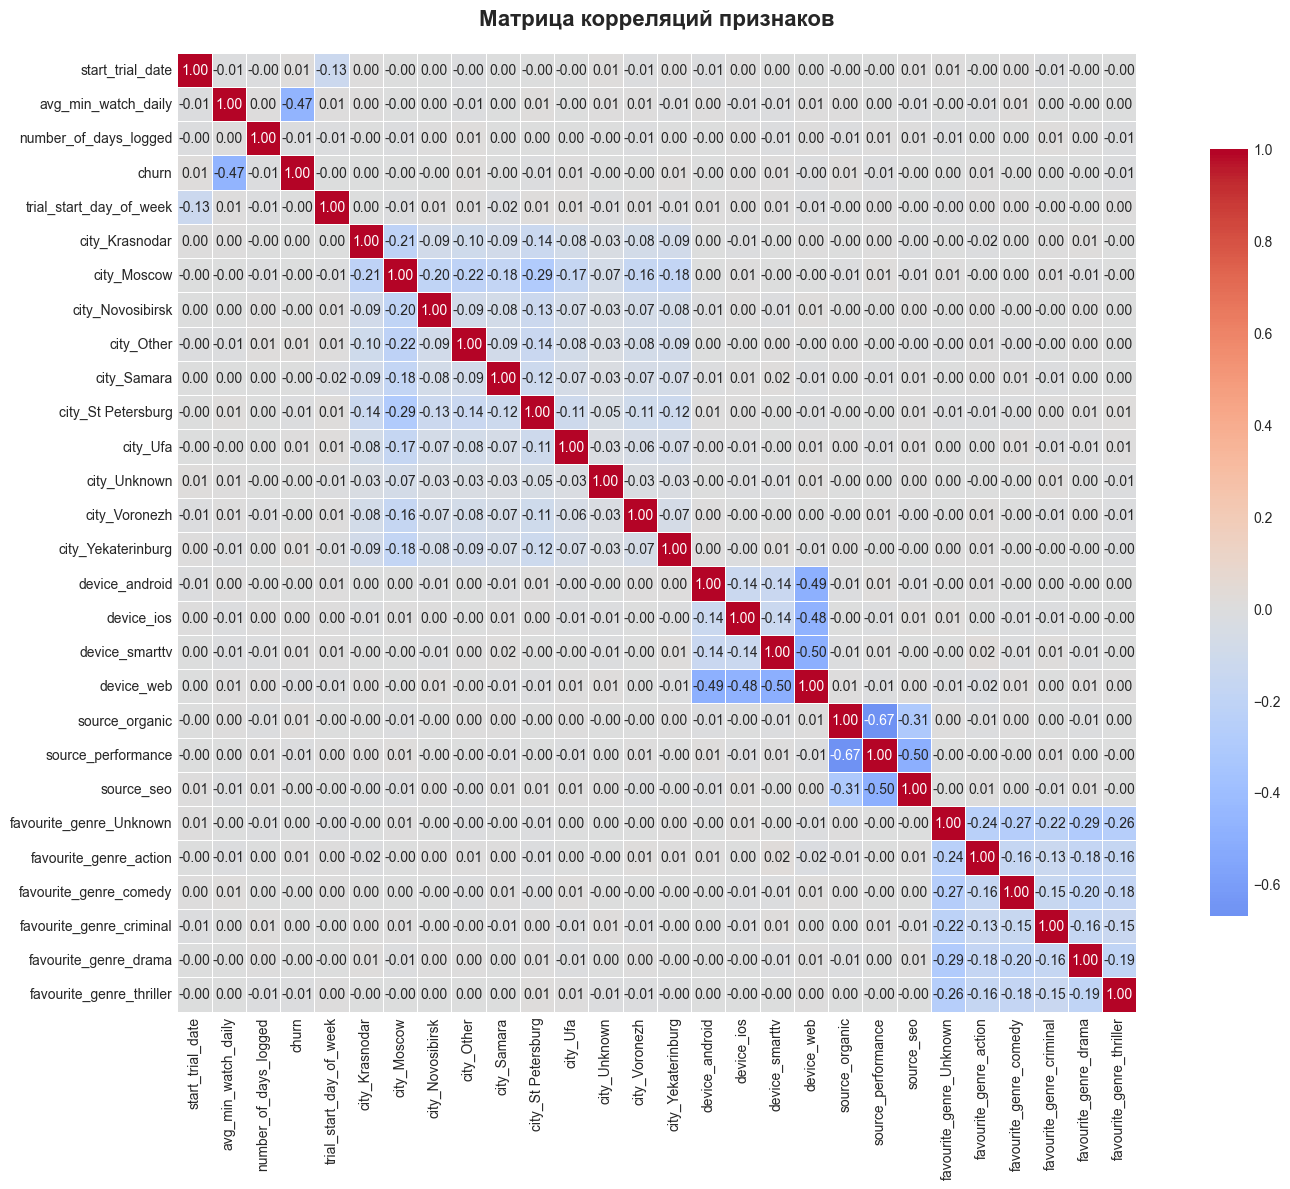

In [17]:
# Строим тепловую диаграмму
correlation_matrix = data_encoded.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8})

plt.title("Матрица корреляций признаков", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

Наблюдается **отрицательная корреляция** между **churn** и **avg_min_watch_daily** (-0.47) - чем больше время просмотров в день, тем меньше вероятность ухода

# Проанализируем как отток меняется в зависимости от среднего времени просмотра в день.

C:\Users\User\AppData\Local\Temp\ipykernel_17744\2889301486.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('watch_category')['churn'].mean().plot(kind='bar', figsize=(10, 6))


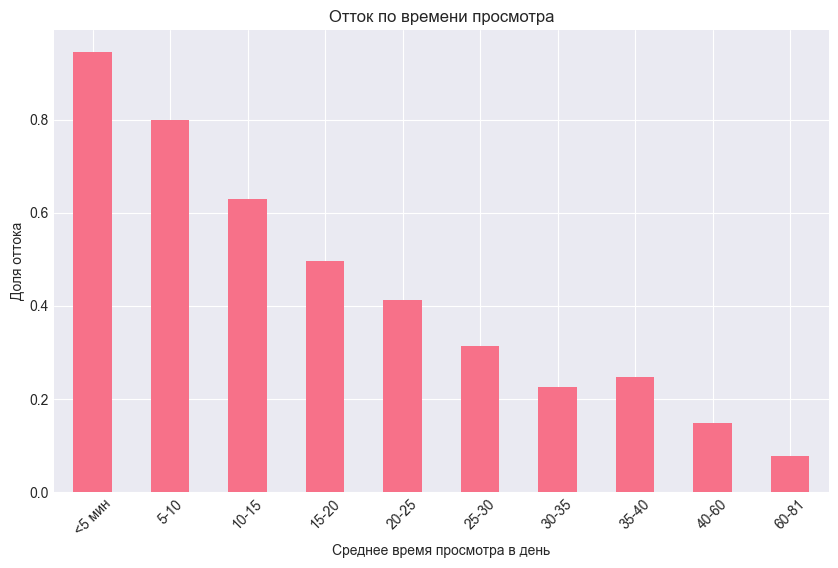

In [18]:
bins_minutes = [0, 5, 10, 15, 20, 25, 30, 35, 40, 60, 81]
labels = ['<5 мин', '5-10', '10-15', '15-20', '20-25', '25-30', '30-35', '35-40', '40-60', '60-81']

df['watch_category'] = pd.cut(df['avg_min_watch_daily'], 
                               bins=bins_minutes, 
                               labels=labels, 
                               right=False)

df.groupby('watch_category')['churn'].mean().plot(kind='bar', figsize=(10, 6))

plt.title('Отток по времени просмотра')
plt.ylabel('Доля оттока')
plt.xlabel('Среднее время просмотра в день')
plt.xticks(rotation=45)
plt.show()

## Гипотеза 1: Среднее время просмотра влияет на покупку

Чем выше среднее время просмотра в день, тем выше конверсия в подписку.

### Стратегия проверки

Разобьем на две группы:

1. те, кто совершил подписку
2. те, кто нет


Проверим, различаются ли статистически у них среднее время просмотра.

### Статистический метод

Тест Манна-Уитни

/var/folders/kq/s68zxdrj5_n8kk2nh3cg7sx40000gn/T/ipykernel_43062/715512862.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


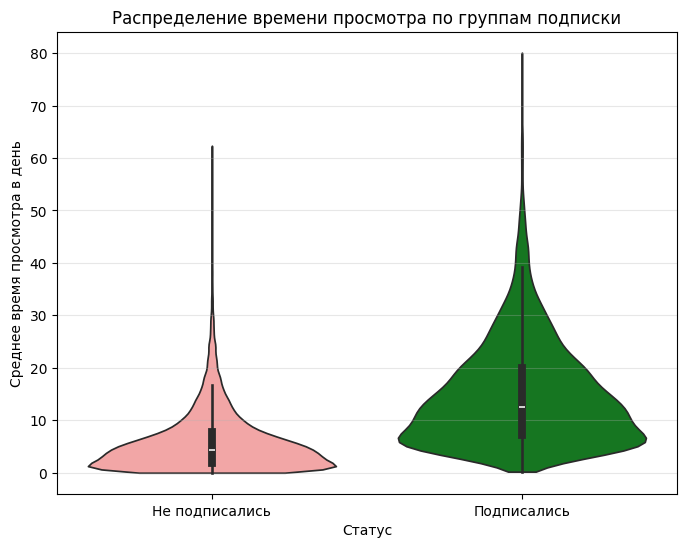

In [40]:
plt.figure(figsize=(8, 6))

df_sorted = df.copy()
df_sorted["churn_str"] = df_sorted["churn"].map({1: "Не подписались", 0: "Подписались"})

sns.violinplot(
    data=df_sorted,
    x="churn_str",
    y="avg_min_watch_daily",
    palette=["#ff9999", "#068615"], 
    cut=0
)

plt.title("Распределение времени просмотра по группам подписки")
plt.xlabel("Статус")
plt.ylabel("Среднее время просмотра в день")
plt.grid(axis="y", alpha=0.3)

plt.show()


Взяли Манна-Уитни, так как у нас ненормальное распределение среднего времени просмотра.


H₀ (нулевая гипотеза): медианное (или среднее) время просмотра у подписавшихся не больше, чем у отписавшихся.

H₁ (альтернативная гипотеза): медианное время просмотра у подписавшихся больше, чем у отписавшихся.

In [29]:
df["converted"] = (df["churn"] == 0).astype(int)
group_buy = df[df["converted"] == 1]["avg_min_watch_daily"]
group_not = df[df["converted"] == 0]["avg_min_watch_daily"]


In [30]:
x = group_buy.values
y = group_not.values

median_buy = np.median(x)
median_not = np.median(y)
# ранги
all_vals = np.concatenate([x, y])
ranks = np.argsort(np.argsort(all_vals)) + 1

# ранги обратно в группы
r_x = ranks[:len(x)]
r_y = ranks[len(x):]

# U-статистика
U1 = r_x.sum() - len(x)*(len(x)-1)/2
U2 = r_y.sum() - len(y)*(len(y)-1)/2
U = min(U1, U2)

# мат. ожидание и дисперсия
mu = len(x)*len(y)/2
sigma = np.sqrt(len(x)*len(y)*(len(x)+len(y)+1)/12)

# Z-оценка
Z = (U - mu) / sigma

# p-value через нормальное распределение
from math import erf, sqrt
p_value = 2 * (1 - 0.5 * (1 + erf(abs(Z) / sqrt(2))))

print("🔎 Результаты теста Манна–Уитни на различие среднего времени просмотра\n")
print(f"Медианное время просмотра (подписались): {median_buy:.2f} мин/день")
print(f"Медианное время просмотра (не подписались): {median_not:.2f} мин/день\n")
print(f"U-статистика: {U:.2f}")
print(f"Z-значение: {Z:.2f}")
print(f"p-value: {p_value:.3g}\n")

if p_value < 0.05:
    print("Вывод: различия статистически значимы (p < 0.05).**")
    if mean_buy > mean_not:
        print("Пользователи, которые **подписались**, смотрели **существенно больше.")
    else:
        print("Не подписавшиеся смотрели больше (что маловероятно для такой задачи).")
else:
    print("Вывод: статистически значимых различий НЕ обнаружено.")

print("\nИнтерпретация:")
print("Чем больше пользователь смотрит в триал, тем выше вероятность, что он купит подписку.")
print("Этот признак — сильный маркер вовлечённости и должен использоваться в модели.")

🔎 Результаты теста Манна–Уитни на различие среднего времени просмотра

Медианное время просмотра (подписались): 12.62 мин/день
Медианное время просмотра (не подписались): 4.38 мин/день

U-статистика: 23617448.00
Z-значение: -75.38
p-value: 0

Вывод: различия статистически значимы (p < 0.05).**
Пользователи, которые **подписались**, смотрели **существенно больше.

Интерпретация:
Чем больше пользователь смотрит в триал, тем выше вероятность, что он купит подписку.
Этот признак — сильный маркер вовлечённости и должен использоваться в модели.


/var/folders/kq/s68zxdrj5_n8kk2nh3cg7sx40000gn/T/ipykernel_43062/374079110.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


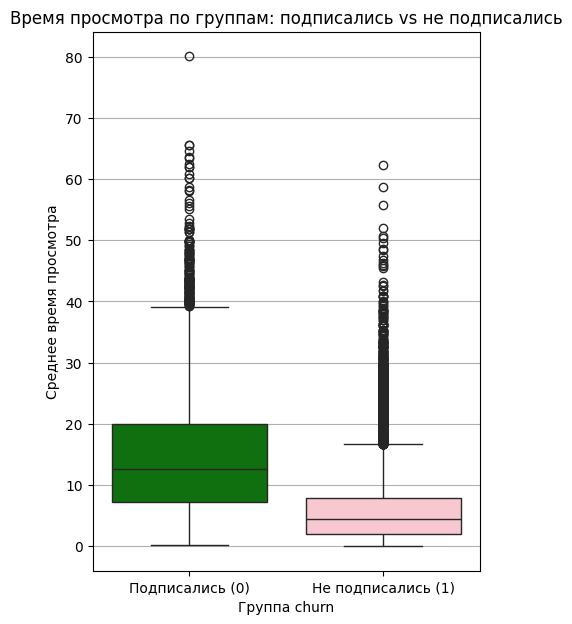

In [31]:
plt.figure(figsize=(5, 7))
sns.boxplot(
    data=df,
    x="churn",
    y="avg_min_watch_daily",
    palette={"0": "green", "1": "pink"}
)

plt.xticks([0, 1], ["Подписались (0)", "Не подписались (1)"])
plt.title("Время просмотра по группам: подписались vs не подписались")
plt.xlabel("Группа churn")
plt.ylabel("Среднее время просмотра")
plt.grid(axis='y')

plt.show()


**Гипотеза 1 подтверждена. Пользователи с более высоким средним временем просмотра значительно чаще покупают подписку.**

Разница по Манна–Уитни: Z = –75.4, p < 0.001

Это означает, что распределения существенно различаются.

Глубина просмотра - важдый маркер конверсии.


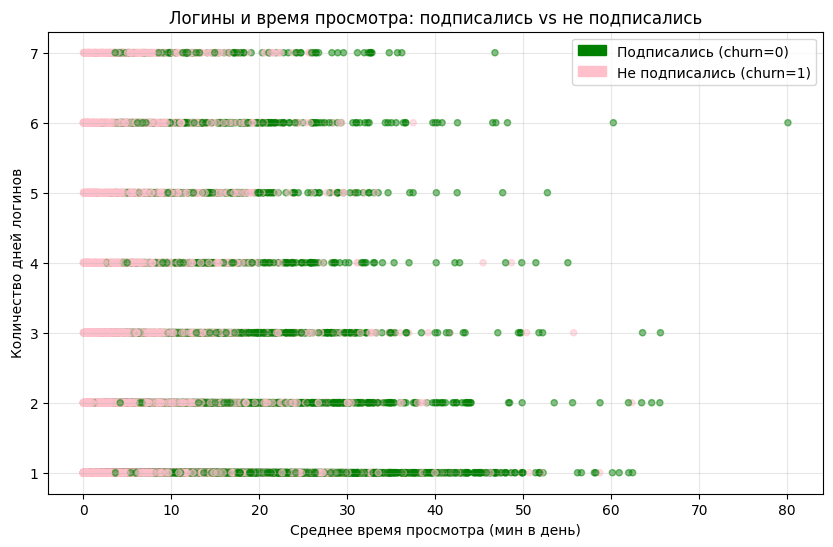

In [32]:
colors = df["churn"].map({0: "green", 1: "pink"})

plt.figure(figsize=(10, 6))

plt.scatter(
    df["avg_min_watch_daily"],
    df["number_of_days_logged"],
    c=colors,
    alpha=0.5,
    s=20,
)

plt.xlabel("Среднее время просмотра (мин в день)")
plt.ylabel("Количество дней логинов")
plt.title("Логины и время просмотра: подписались vs не подписались")

import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='green', label='Подписались (churn=0)')
pink_patch  = mpatches.Patch(color='pink', label='Не подписались (churn=1)')
plt.legend(handles=[green_patch, pink_patch])

plt.grid(True, alpha=0.3)
plt.show()

Даже если пользователь заходил 1-2 но смотрел больше 10-20 минут вероятность подписку выше, чес у тех кто был в сервисе меньше 10 минут;

С дрегой строны даже 7 дней подключений, не гарантируют подключение платной подписки, там так же есть большое количество отписавшихся среди тех кто смотрел меньше 10 дней.

Посмотрим дальше насколько это достоверно.

### Двухфакторный анализ — метод множественной логистической регрессии
Проверяем, является ли avg_min_watch_daily значимым предиктором после учёта number_of_days_logged.

Логистическая регрессия проверяет значимость коэффициентов.Поэтому нулевая и альтернативная гипотезы следующие:

*Для переменной avg_min_watch_daily:*

H0: avg_min_watch_daily не влияет на отток

H1: avg_min_watch_daily влияет на отток


*Для переменной number_of_days_logged:*

H0: number_of_days_logged не влияет на отток

H1: number_of_days_logged влияет на отток

In [34]:
df2 = df[["avg_min_watch_daily", "number_of_days_logged", "churn"]].copy()
X = df2[["avg_min_watch_daily", "number_of_days_logged"]]
X = sm.add_constant(X)
y = df2["churn"]

model = sm.Logit(y, X).fit()
print(model.summary())

Optimization terminated successfully.
         Current function value: 0.413362
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                  churn   No. Observations:                28000
Model:                          Logit   Df Residuals:                    27997
Method:                           MLE   Df Model:                            2
Date:                Wed, 10 Dec 2025   Pseudo R-squ.:                  0.1972
Time:                        20:47:11   Log-Likelihood:                -11574.
converged:                       True   LL-Null:                       -14417.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                            coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     2.7548      0.036     77.005      0.000       2.685       2.

In [37]:
coef_watch = model.params["avg_min_watch_daily"]
coef_days = model.params["number_of_days_logged"]
coef_watch

np.float64(-0.1489424060693088)

**Посчитаем как влияет дополнительная минута просмотра и дополнительный день входа на конверсию в подписку**


In [39]:
coef_watch = model.params["avg_min_watch_daily"]
coef_days = model.params["number_of_days_logged"]

p_days = model.pvalues["avg_min_watch_daily"]
p_days = model.pvalues["number_of_days_logged"]


or_watch = np.exp(coef_watch)
or_days = np.exp(coef_days)

effect_watch = (1 - or_watch) * 100
effect_days = (1 - or_days) * 100

print("Интерпретация логистической регрессии")

print(f"Коэффициент avg_min_watch_daily = {coef_watch:.4f}")
print(f"P-value для времени просмотра: {p_days:.4f}")
print(f"Odds ratio = {or_watch:.4f}")
print(f"Каждая дополнительная минута просмотра снижает шансы отписки на {effect_watch:.2f}%\n")

print(f"Коэффициент number_of_days_logged = {coef_days:.4f}")
print(f"P-value для числа дней логинов: {p_days:.4f}")
print(f"Odds ratio = {or_days:.4f}")
print(f"Каждый дополнительный день логина снижает шансы отписки на {effect_days:.2f}%")

Интерпретация логистической регрессии
Коэффициент avg_min_watch_daily = -0.1489
P-value для времени просмотра: 0.0352
Odds ratio = 0.8616
Каждая дополнительная минута просмотра снижает шансы отписки на 13.84%

Коэффициент number_of_days_logged = -0.0233
P-value для числа дней логинов: 0.0352
Odds ratio = 0.9769
Каждый дополнительный день логина снижает шансы отписки на 2.31%


Ключевым драйвером покупки подписки является не просто факт захода в сервис, а глубина просмотра контента.

Нужно сосредоточиться на времени удержания клиента, например лучше настроить систему рекомендаций.

Или с другой стороны сделать какую-то модель которая будет предсказывать холодных клиентов которые смотрят до 5-10 минут в день и не тратить на них рекламные бюджеты.

# Проанализируем какое минимальное время просмотра защищает от оттока

In [19]:
# Анализ пороговых значений для времени просмотра
threshold_analysis = []
for threshold in [5, 10, 15, 30, 60]:
    churn_below = df[df['avg_min_watch_daily'] < threshold]['churn'].mean()
    churn_above = df[df['avg_min_watch_daily'] >= threshold]['churn'].mean()
    threshold_analysis.append({
        'threshold': threshold,
        'churn_below': churn_below,
        'churn_above': churn_above,
        'diff': churn_below - churn_above
    })

threshold_df = pd.DataFrame(threshold_analysis)
print("\nАнализ порогов для времени просмотра:")
print(threshold_df)


Анализ порогов для времени просмотра:
   threshold  churn_below  churn_above      diff
0          5     0.944513     0.654175  0.290338
1         10     0.891101     0.508850  0.382252
2         15     0.853723     0.405466  0.448257
3         30     0.802102     0.205980  0.596122
4         60     0.789617     0.076923  0.712694


## Гипотеза 2. Порог ценности в 30 минут просмотра влияет на вероятность оттока

Порог 30 мин. Пользователи кто смотрит < 30 минут уходит в 80% случаев (не видит ценности), кто более 30 минут уходит в 20% случаев (видит ценность, возможно смотрит какой-то конкретный контент).

### Стратегия проверки

Разделим пользователей на 2 группы:
1. пользователи с avg_min_watch_daily < 30 минут
2. пользователи с avg_min_watch_daily ≥ 30 минут.

Проверим, различается ли статистически доля оттока в каждой группе.

### Статистический метод

Z-тест для пропорций (основной метод) и доверительные интервалы.

# Проанализируем как конверсия меняется в зависимости от количества дней логинов в триал

In [20]:
conversion_by_days = (
    df.groupby("number_of_days_logged")
      .apply(lambda x: 1 - x["churn"].mean()) 
      .reset_index(name="conversion_rate")
)

conversion_by_days

,number_of_days_logged,conversion_rate
0,1,0.207200
1,2,0.214069
2,3,0.211823
3,4,0.224903
4,5,0.204365
5,6,0.242481
6,7,0.212185


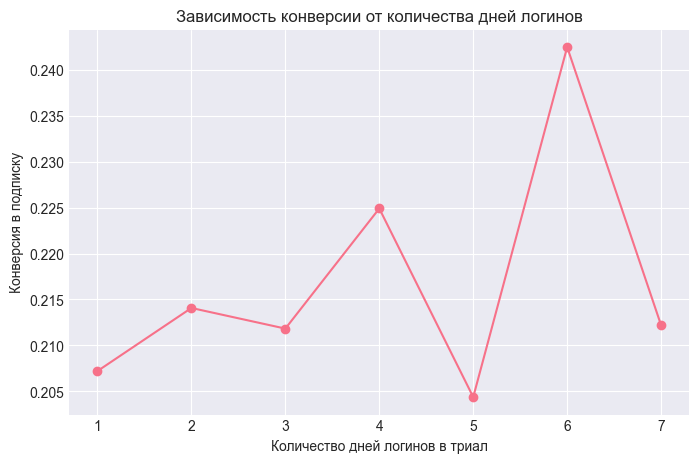

In [21]:
plt.figure(figsize=(8,5))
plt.plot(
    conversion_by_days["number_of_days_logged"],
    conversion_by_days["conversion_rate"],
    marker="o"
)

plt.xlabel("Количество дней логинов в триал")
plt.ylabel("Конверсия в подписку")
plt.title("Зависимость конверсии от количества дней логинов")
plt.grid(True)
plt.show()

Наблюдается **спад конверсии на 5 и 7 дни**. Люди теряют интерес или пользуются только пробным периодом, а затем уходят

## Гипотеза 3: Конверсия падает на 5-й день триала

Спад конверсии на 5-й день триала (20.4% против 22.5% на 4-й день) обусловлен тем, что пользователи, которые не нашли достаточно ценного контента к середине триала, снижают активность просмотра, что и приводит к снижению конверсии.

### Стратегия проверки

Разделим пользователей на 2 группы:
1. те, которые были активны на 5-й день и совершили подписку
2. те, которые были активны на 5-й день и не совершили подписку.

Чтобы проверить, предсказывает ли активность перед спадом сам спад конверсии, проанализируем среднее время просмотра на 4-й день триала (день перед спадом).

### Статистический метод

Тест Манна-Уитни

# Проанализируем связь географии (городов), времени просмотров пользователей и отток

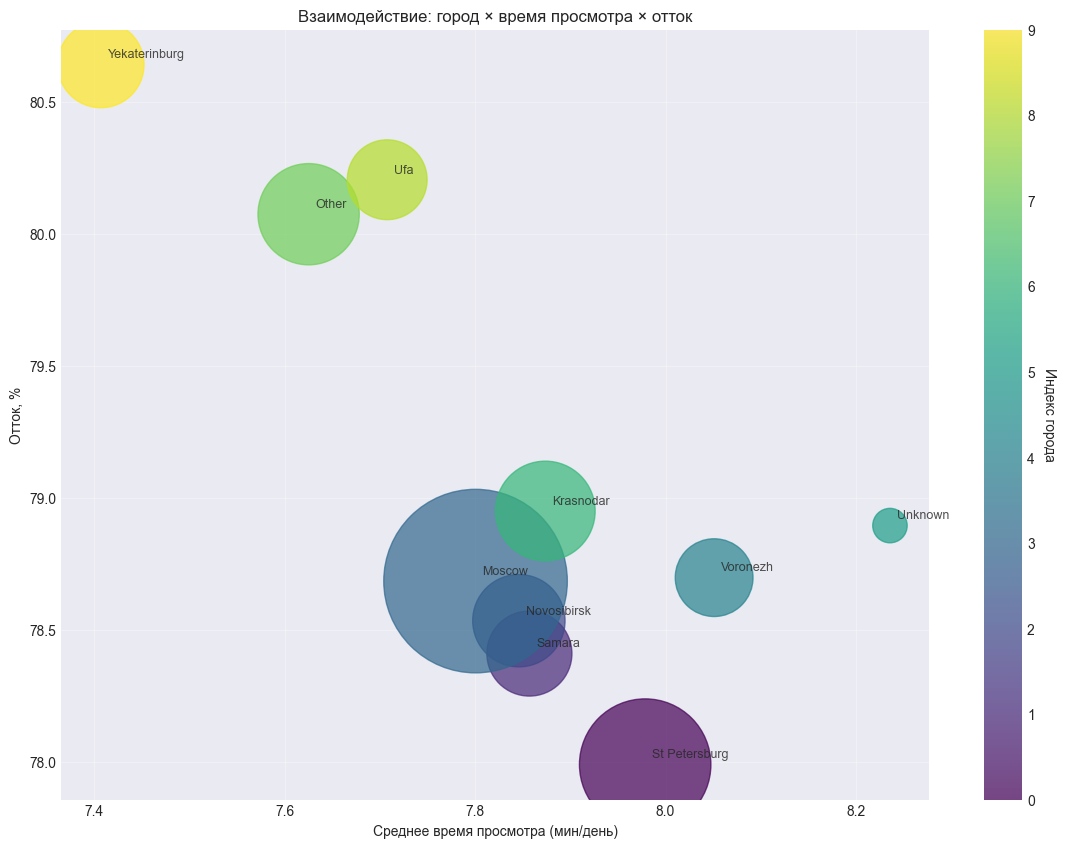

In [22]:
# График зависимости город х время просмотра х отток
city_watch_interaction = df.groupby('city').agg({
    'churn': 'mean',
    'avg_min_watch_daily': 'mean',
    'user_id': 'count'
}).rename(columns={'user_id': 'count', 'churn': 'churn_rate'})

city_watch_interaction['churn_rate_percent'] = city_watch_interaction['churn_rate'] * 100
city_watch_interaction = city_watch_interaction.sort_values('churn_rate_percent')

plt.figure(figsize=(14, 10))

scatter = plt.scatter(city_watch_interaction['avg_min_watch_daily'],
                            city_watch_interaction['churn_rate_percent'],
                            s=city_watch_interaction['count']*2,
                            alpha=0.7,
                            c=range(len(city_watch_interaction)),
                            cmap='viridis')

for city, row in city_watch_interaction.iterrows():
   plt.annotate(city,
                       xy=(row['avg_min_watch_daily'], row['churn_rate_percent']),
                       xytext=(5, 5), textcoords='offset points',
                       fontsize=9, alpha=0.8)

plt.xlabel('Среднее время просмотра (мин/день)')
plt.ylabel('Отток, %')
plt.title('Взаимодействие: город × время просмотра × отток')
plt.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter)
cbar.set_label('Индекс города', rotation=270, labelpad=15)

## Гипотеза 4: Географический фактор влияет на отток

Географический фактор (город) является значимым предиктором оттока. Пользователи в Екатеринбурге и Уфе демонстрируют паттерны поведения, отличные от других регионов: меньшее время просмотра при более высоком оттоке.

### Стратегия проверки

Разделим пользователей на 2 группы:
1. из Екатеринбурга и Уфы (проблемные города)
2. из остальных городов

### Статистический метод

Сравнение времени просмотра между группами - тест Манна-Уитни, оттока - Z-тест для пропорций.